In [5]:
import sys
sys.path.append("../src")

from dataset import get_dataloaders

print("Loading dataloaders...")
loaders = get_dataloaders(
    data_dir="../data/processed",
    batch_size=32,
    num_workers=2   # safe default for Windows
)

print(f"\nBatches per split:")
for name, loader in loaders.items():
    print(f"  {name:5s}: {len(loader):,} batches "
          f"x batch_size {loader.batch_size} = "
          f"~{len(loader)*loader.batch_size:,} images")



Loading dataloaders...
  train: 84,044 images | open=41,085 closed=42,959
  val  : 21,056 images | open=10,456 closed=10,600
  test : 21,063 images | open=10,464 closed=10,599

Batches per split:
  train: 2,626 batches x batch_size 32 = ~84,032 images
  val  : 658 batches x batch_size 32 = ~21,056 images
  test : 659 batches x batch_size 32 = ~21,088 images


In [6]:
# Grab exactly ONE batch from each loader and check shapes
for split, loader in loaders.items():
    imgs, labels = next(iter(loader))
    print(f"\n{split}:")
    print(f"  imgs shape   : {imgs.shape}")    # must be (32, 3, 224, 224)
    print(f"  labels shape : {labels.shape}")  # must be (32,)
    print(f"  imgs dtype   : {imgs.dtype}")    # must be torch.float32
    print(f"  labels dtype : {labels.dtype}")  # must be torch.int64
    print(f"  imgs min/max : {imgs.min():.3f} / {imgs.max():.3f}")
    # min ~= -2.1, max ~= 2.6 (normalised with ImageNet stats)
    print(f"  unique labels: {labels.unique().tolist()}")
    # must be [0, 1] or [0] or [1] depending on batch


train:
  imgs shape   : torch.Size([32, 3, 224, 224])
  labels shape : torch.Size([32])
  imgs dtype   : torch.float32
  labels dtype : torch.int64
  imgs min/max : -2.118 / 2.640
  unique labels: [0, 1]

val:
  imgs shape   : torch.Size([32, 3, 224, 224])
  labels shape : torch.Size([32])
  imgs dtype   : torch.float32
  labels dtype : torch.int64
  imgs min/max : -2.084 / 2.640
  unique labels: [0]

test:
  imgs shape   : torch.Size([32, 3, 224, 224])
  labels shape : torch.Size([32])
  imgs dtype   : torch.float32
  labels dtype : torch.int64
  imgs min/max : -2.101 / 2.640
  unique labels: [0]


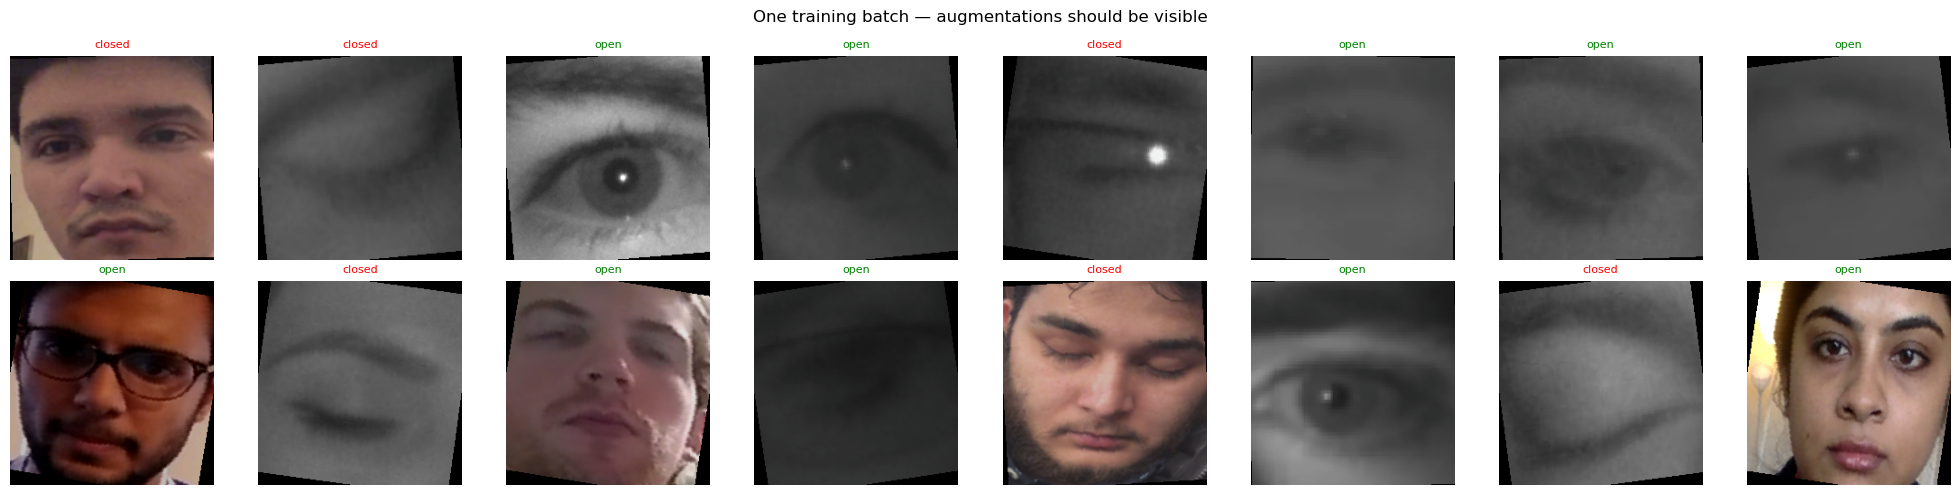

In [7]:
import torch, matplotlib.pyplot as plt
import numpy as np

def unnormalise(t):
    """Convert normalised tensor back to viewable image."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

imgs, labels = next(iter(loaders["train"]))
label_names = {0: "open", 1: "closed"}

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for ax, img, label in zip(axes.flat, imgs, labels):
    ax.imshow(unnormalise(img))
    name = label_names[label.item()]
    ax.set_title(name, fontsize=8,
                 color="green" if name=="open" else "red")
    ax.axis("off")
plt.suptitle("One training batch — augmentations should be visible")
plt.tight_layout()
plt.savefig("../outputs/dataloader_batch_check.png",
            dpi=120, bbox_inches="tight")
plt.show()
# You should see: varied brightness, slight rotations, occasional flips
# Labels should match the eye state you see in the image

In [8]:
import time

loader = loaders["train"]
start  = time.time()
for i, (imgs, labels) in enumerate(loader):
    if i == 9: break   # time just 10 batches
elapsed = time.time() - start

rate = 10 / elapsed
print(f"10 batches in {elapsed:.1f}s → {rate:.1f} batches/sec")
print(f"Estimated time to load all {len(loader):,} train batches: "
      f"{len(loader)/rate/60:.1f} min per epoch (data loading only)")

if rate < 2:
    print("\nDataLoader is slow. Try num_workers=2 if on Linux/Colab.")
elif rate < 5:
    print("\nDataLoader speed is acceptable.")
else:
    print("\nDataLoader speed is good.")

10 batches in 26.3s → 0.4 batches/sec
Estimated time to load all 2,626 train batches: 114.9 min per epoch (data loading only)

DataLoader is slow. Try num_workers=2 if on Linux/Colab.
